In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Dirichlet
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import math, numpy as np


# =========================================
# 0. Constants and other Parameters
# =========================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =========================================
# 1. Dirichlet Sampler
# =========================================
class DirichletSampler:
    def __init__(self, alpha):
        self.alpha = torch.tensor(alpha, dtype=torch.float)
        self.dist = Dirichlet(self.alpha)

    def sample(self):
        return self.dist.rsample()

# =========================================
# 2. ReinMax / Straight-Through Estimator
# =========================================
class ReinMaxSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits):
        probs = F.softmax(logits, dim=-1)
        idx = probs.argmax(dim=-1)
        one_hot = F.one_hot(idx, num_classes=logits.size(-1)).type_as(logits)
        ctx.save_for_backward(probs)
        return one_hot

    @staticmethod
    def backward(ctx, grad_output):
        (probs,) = ctx.saved_tensors
        return grad_output * probs * (1 - probs)

reinforce_max = ReinMaxSTE.apply

# =========================================
# 3. Choice Block & Cell Definition
# =========================================
class ChoiceBlock(nn.Module):
    def __init__(self, ops, dropout_p=0.0):
        super().__init__()
        self.ops = nn.ModuleList(ops)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x, logits):
        mask = reinforce_max(logits)
        for i, op in enumerate(self.ops):
            if mask[i] > 0:
                return self.dropout(op(x))
        return x

class Cell(nn.Module):
    def __init__(self, C, dropout_p=0.2, num_nodes=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_edges = sum(2 + i for i in range(num_nodes + 1))
        self.blocks = nn.ModuleList([
            ChoiceBlock([
                nn.Sequential(nn.Conv2d(C, C, 3, padding=1, groups=C), nn.Conv2d(C, C, 1)),
                nn.Sequential(nn.Conv2d(C, C, 5, padding=2, groups=C), nn.Conv2d(C, C, 1)),
                nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1), nn.Conv2d(C, C, 1)),
                nn.Identity()
            ], dropout_p=dropout_p)
            for _ in range(self.num_edges)
        ])

    def forward(self, s0, s1, logits):
        states = [s0, s1]
        offset = 0
        for _ in range(self.num_nodes):
            nb = len(states)
            node = sum(self.blocks[offset + j](h, logits[offset + j]) for j, h in enumerate(states))
            states.append(node)
            offset += nb
        return states[-1]



# -----------------------------------------
# 1) More expressive primitives
# -----------------------------------------
def sep_conv(C, kernel_size, stride, padding):
    """Depthwise-Separable Conv + BN + ReLU"""
    return nn.Sequential(
        nn.ReLU(inplace=False),
        nn.Conv2d(C, C, kernel_size, stride, padding,
                  groups=C, bias=False),
        nn.Conv2d(C, C, 1, bias=False),
        nn.BatchNorm2d(C),
    )

def dil_conv(C, kernel_size, stride, padding, dilation):
    """Dilated Conv + BN + ReLU"""
    return nn.Sequential(
        nn.ReLU(inplace=False),
        nn.Conv2d(C, C, kernel_size, stride,
                  padding, dilation=dilation, bias=False),
        nn.BatchNorm2d(C),
    )

def skip_connect():
    return nn.Identity()

def avg_pool(C, kernel_size, stride, padding):
    return nn.AvgPool2d(kernel_size, stride=stride, padding=padding)

def max_pool(C, kernel_size, stride, padding):
    return nn.MaxPool2d(kernel_size, stride=stride, padding=padding)

# -----------------------------------------
# 2) Improved ChoiceBlock with soft mixing
# -----------------------------------------
class MixedOp(nn.Module):
    def __init__(self, C):
        super().__init__()
        self._ops = nn.ModuleList([
            sep_conv(C, 3, 1, 1),
            sep_conv(C, 5, 1, 2),
            dil_conv(C, 3, 1, 2, dilation=2),
            nn.Sequential(nn.ReLU(inplace=False),
                          nn.Conv2d(C, C, 1, bias=False),
                          nn.BatchNorm2d(C)),
            avg_pool(C, 3, 1, 1),
            skip_connect(),
        ])

    def forward(self, x, weights):
        # weights: a (num_ops,) softmaxed vector
        return sum(w * op(x) for w, op in zip(weights, self._ops))

# -----------------------------------------
# 3) Bottleneck + residual Cell
# -----------------------------------------
class ResidualCell(nn.Module):
    def __init__(self, C, num_nodes=4):
        """
        - num_nodes: how many intermediate states per cell
        - uses a 1x1 bottleneck before mixed ops to reduce compute
        """
        super().__init__()
        self.num_nodes = num_nodes
        self.preprocess = nn.Sequential(
            nn.Conv2d(C, C, kernel_size=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=False),
        )
        # we'll compute edges from each existing state to each new state
        self.ops = nn.ModuleDict()
        for i in range(num_nodes + 1):    # +1 to include the initial input
            for j in range(i + 1, num_nodes + 1):
                key = f"{i}<-{j}"
                self.ops[key] = MixedOp(C)

        self.postprocess = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C * num_nodes, C, 1, bias=False),
            nn.BatchNorm2d(C),
        )

    def forward(self, s0, weights):
        """
        s0: input feature map
        weights: dict mapping 'i<-j' -> softmax weight vector for that edge
        """
        states = [self.preprocess(s0)]
        # build up intermediate states
        for new_idx in range(1, self.num_nodes + 1):
            sums = 0
            for prev_idx, h in enumerate(states):
                key = f"{prev_idx}<-{new_idx}"
                sums = sums + self.ops[key](h, weights[key])
            states.append(sums)
        # concat all intermediate states (excluding the initial)
        concat = torch.cat(states[1:], dim=1)  # (B, C * num_nodes, H, W)
        return self.postprocess(concat) + s0   # residual

# -----------------------------------------
# 4) How to generate the weights dict
# -----------------------------------------
class CellArchParam(nn.Module):
    def __init__(self, C, num_nodes=4, num_ops=6):
        super().__init__()
        # one learnable vector per edge
        self.alphas = nn.ParameterDict()
        for i in range(num_nodes + 1):
            for j in range(i + 1, num_nodes + 1):
                self.alphas[f"{i}<-{j}"] = nn.Parameter(
                    1e-3 * torch.randn(num_ops)
                )

    def forward(self, logits_slice):
        # logits_slice: Tensor [num_edges_this_cell, num_ops]
        return {
            key: F.softmax(logits_slice[i], dim=-1)
            for i, key in enumerate(self.alphas.keys())
        }


# =========================================
# 4. HyperNetwork
# =========================================
class HyperNetwork(nn.Module):
    def __init__(self, num_blocks, num_ops, hidden_dim=128, depth=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(2, hidden_dim))
        for _ in range(depth-1):
            layers += [
                nn.ReLU(inplace=False),
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim)      # ← use LayerNorm instead
            ]
        self.mlp    = nn.Sequential(*layers)
        self.fc_out = nn.Linear(hidden_dim, num_blocks * num_ops)
        self.num_blocks = num_blocks
        self.num_ops    = num_ops

    def forward(self, lambda_vec):
        # allow lambda_vec to be either [2] or [B,2]
        x = lambda_vec
        if x.dim() == 1:
            x = x.unsqueeze(0)         # now [1,2]
        h = self.mlp(x)                # [B, hidden_dim]
        out = self.fc_out(h)           # [B, num_blocks*num_ops]
        out = out.view(-1, self.num_blocks, self.num_ops)
        if lambda_vec.dim() == 1:
            out = out.squeeze(0)       # back to [num_blocks, num_ops]
        return out


# =========================================
# 5. SuperNetwork (Classification Only)
# =========================================

class SuperNetwork(nn.Module):
    def __init__(self, C=16, num_cells=4, num_nodes=4, num_ops=6, dropout_p=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, C, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=False),
            nn.Dropout(dropout_p)
        )
        self.cells = nn.ModuleList()
        for _ in range(num_cells):
            # Each cell has its own architecture params and residual cell
            arch_param = CellArchParam(C, num_nodes=num_nodes, num_ops=num_ops)
            cell_body = ResidualCell(C, num_nodes=num_nodes)
            self.cells.append(nn.ModuleDict({
                'arch': arch_param,
                'body': cell_body
            }))
        
        # after all cells are added, record counts:
        self.num_blocks = sum(len(cell['arch'].alphas) for cell in self.cells)
        # all alphas share same op‐dim:
        first_alpha = next(iter(self.cells[0]['arch'].alphas.values()))
        self.num_ops   = first_alpha.shape[0]

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(C, 10)
        )

    def forward(self, x, arch_logits):
        out = self.stem(x)
        offset = 0
        for cell in self.cells:
            # num_edges for this cell
            ne = len(cell['arch'].alphas)
            # grab the right chunk
            logits_slice = arch_logits[offset:offset+ne]  # [ne, num_ops]
            weights      = cell['arch'](logits_slice)     # softmax over each row
            out          = cell['body'](out, weights)
            offset      += ne
        gap = self.global_pool(out).view(x.size(0), -1)
        return self.cls_head(gap)


# =========================================
# 6. MGDA Solver for 2 Tasks
# =========================================
def solve_mgda_weights(M, iters=50, lr=1e-1, device='cpu'):
    k = M.shape[0]
    alpha = torch.full((k,), 1.0/k, device=device)
    for _ in range(iters):
        grad_alpha = 2 * M @ alpha
        alpha = alpha - lr * grad_alpha
        u, _ = torch.sort(alpha, descending=True)
        cssv = torch.cumsum(u, dim=0) - 1
        n = torch.arange(1, k+1, device=device, dtype=cssv.dtype)
        mask = u * n > cssv
        rho = torch.nonzero(mask, as_tuple=False)[-1, 0]
        theta = cssv[rho] / (rho.float() + 1)
        alpha = torch.clamp(alpha - theta, min=0)
    return alpha

# =========================================
# 7. Training Loop (Classification + Size)
# =========================================

def train(num_epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ————— Data —————
    transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    cifar     = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=transform)
    train_set, val_set = random_split(cifar, [45000, 5000])
    train_loader = DataLoader(train_set, batch_size=128,
                              shuffle=True, num_workers=4)
    val_loader   = DataLoader(val_set,   batch_size=128,
                              shuffle=False, num_workers=4)

    # ————— Model & Search —————
    sampler     = DirichletSampler([10.0, 1.0])  # cls vs size
    supernet    = SuperNetwork().to(device)
    num_blocks = supernet.num_blocks
    num_ops    = supernet.num_ops
    hypernet    = HyperNetwork(num_blocks, num_ops).to(device)


    # ————— Opts & Loss —————
    opt_w       = torch.optim.SGD(supernet.parameters(),
                                  lr=0.025, momentum=0.9,
                                  weight_decay=3e-4)
    opt_theta   = torch.optim.SGD(hypernet.parameters(),
                                  lr=0.01, momentum=0.9)
    criterion   = nn.CrossEntropyLoss()

    # ————— Precompute size counts —————
    op_counts = []
    for cell in supernet.cells:
        body: ResidualCell = cell['body']
        # body.ops is a ModuleDict mapping edge-key -> MixedOp
        for mixed_op in body.ops.values():
            # mixed_op._ops is the list of nn.Modules we mix over
            sizes = [sum(p.numel() for p in op.parameters())
                     for op in mixed_op._ops]
            op_counts.append(sizes)

    counts = torch.tensor(op_counts, device=device, dtype=torch.float)
    # per‐edge maximum
    max_per_edge = counts.max(dim=1).values     # shape [num_edges]

    # total worst‐case size
    max_size     = max_per_edge.sum()           # scalar

    # ————— Training Loop —————
    epoch_iter = tqdm(range(1, num_epochs+1),
                      desc="Overall Training", unit="epoch")
    for epoch in epoch_iter:
        supernet.train()
        hypernet.train()

        # 1) Sample λ for this epoch
        lambda_vec = sampler.sample().to(device)

        # 2) HyperNet update on one held-out batch
        x_val, y_val = next(iter(val_loader))
        x_val, y_val = x_val.to(device), y_val.to(device)

        arch_logits = hypernet(lambda_vec)
        out_val     = supernet(x_val, arch_logits)

        loss_cls   = criterion(out_val, y_val)
        loss_size  = (reinforce_max(arch_logits) * counts).sum() / max_size

        # build per-objective grads
        grads = []
        for loss in (loss_cls, loss_size):
            g = torch.autograd.grad(loss, hypernet.parameters(),
                                    retain_graph=True,
                                    allow_unused=True)
            flat = torch.cat([
                (gi if gi is not None else torch.zeros_like(p)).flatten()
                for gi, p in zip(g, hypernet.parameters())
            ])
            grads.append(flat / (flat.norm() + 1e-8))

        # MGDA solve
        G     = torch.stack(grads)          # [2, D]
        M     = G @ G.T                     # [2×2]
        alpha = solve_mgda_weights(M, device=device)

        # combine & step
        comb   = alpha[0]*grads[0] + alpha[1]*grads[1]
        offset = 0
        for p in hypernet.parameters():
            n = p.numel()
            p.grad = comb[offset:offset+n].view_as(p)
            offset += n

        opt_theta.zero_grad()
        opt_theta.step()

        # 3) SuperNet update (cls only) w/ tqdm
        cls_ray = torch.tensor([1.0, 0.0], device=device)
        train_iter = tqdm(train_loader,
                          desc=f"Epoch {epoch:02d} | Weight update",
                          leave=False, unit="batch")
        for x_tr, y_tr in train_iter:
            x_tr, y_tr = x_tr.to(device), y_tr.to(device)

            arch_logits = hypernet(cls_ray)
            out_tr      = supernet(x_tr, arch_logits)
            loss_tr     = criterion(out_tr, y_tr)

            opt_w.zero_grad()
            loss_tr.backward()
            opt_w.step()

            train_iter.set_postfix_str(
                f"cls_loss: {loss_tr.item():.4f}"
            )

        # 4) Log the hypernet (val) losses every epoch
        epoch_iter.set_postfix({
            'val_cls':  f"{loss_cls.item():.4f}",
            'val_size': f"{loss_size.item():.4f}"
        })


    torch.save({'supernet': supernet.state_dict(), 'hypernet': hypernet.state_dict()}, 'checkpoint.pth')

if __name__ == "__main__":
    train(10)


Overall Training:  10%|█         | 1/10 [00:20<03:05, 20.61s/epoch, val_cls=2.4519, val_size=0.2036]


KeyboardInterrupt: 

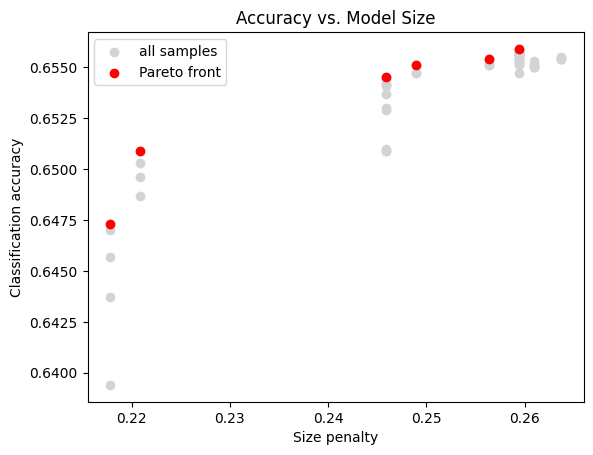

In [6]:
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

def evaluate(supernet, arch_logits, counts_tensor, max_size, device):
    """
    Evaluate classification accuracy on CIFAR-10 and compute size penalty
    for the architecture defined by arch_logits.
    """
    # ---------- Classification Evaluation ----------
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    cifar_val = datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform
    )
    loader = DataLoader(cifar_val, batch_size=256, shuffle=False)

    supernet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = supernet(images, arch_logits)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    cls_acc = correct / total

    # ---------- Size Penalty Computation ----------
    # Straight‐through one‐hot selection
    probs = F.softmax(arch_logits, dim=-1)
    idx = probs.argmax(dim=-1)
    one_hot = F.one_hot(idx, num_classes=arch_logits.size(-1)) \
               .to(device).float()

    size_sum = (one_hot * counts_tensor).sum().item()
    size_penalty = size_sum / max_size

    return {'cls_acc': cls_acc, 'size_penalty': size_penalty}


def is_pareto_efficient(costs):
    """
    Find Pareto-efficient points in a cost array (to minimize each column).
    Returns a boolean mask.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return is_efficient


if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ——— Load checkpoint ———
    chk = torch.load('checkpoint.pth', map_location=device)

    # ——— Reconstruct SuperNetwork ———
    supernet = SuperNetwork().to(device)
    supernet.load_state_dict(chk['supernet'])

    # ——— Derive num_blocks & num_ops from new cells ———
    # Each cell is a ModuleDict with 'arch' (CellArchParam) and 'body' (ResidualCell)
    num_blocks = sum(len(cell['arch'].alphas) for cell in supernet.cells)
    sample_alpha = next(iter(supernet.cells[0]['arch'].alphas.values()))
    num_ops = sample_alpha.shape[0]

    # ——— Reconstruct HyperNetwork (use the same class you trained) ———
    hypernet    = HyperNetwork(num_blocks, num_ops).to(device)
    hypernet.load_state_dict(chk['hypernet'])

    # ——— Recompute counts_tensor & max_size from MixedOp._ops ———
    op_counts = []
    for cell in supernet.cells:
        body: ResidualCell = cell['body']
        for mixed_op in body.ops.values():
            sizes = [sum(p.numel() for p in op.parameters())
                     for op in mixed_op._ops]
            op_counts.append(sizes)
    counts_tensor = torch.tensor(op_counts, device=device, dtype=torch.float)
    max_size = sum(counts_tensor.max(dim=-1).values).item()


    # ——— Sample & evaluate ———
    sampler = DirichletSampler([10.0, 1.0])
    n_samples = 60
    metrics = []
    for _ in range(n_samples):
        lambda_vec = sampler.sample().to(device)
        arch_logits = hypernet(lambda_vec)
        res = evaluate(supernet, arch_logits,
                       counts_tensor, max_size, device)
        metrics.append([res['cls_acc'], res['size_penalty']])
    metrics = np.array(metrics)

    # ——— Pareto front ———
    costs = np.stack([-metrics[:,0], metrics[:,1]], axis=1)
    pareto_mask = is_pareto_efficient(costs)

    # ——— Plot ———
    plt.scatter(metrics[:,1], metrics[:,0],
                c='lightgray', label='all samples')
    plt.scatter(metrics[pareto_mask,1], metrics[pareto_mask,0],
                c='red', label='Pareto front')
    plt.xlabel('Size penalty')
    plt.ylabel('Classification accuracy')
    plt.title('Accuracy vs. Model Size')
    plt.legend()
    plt.show()


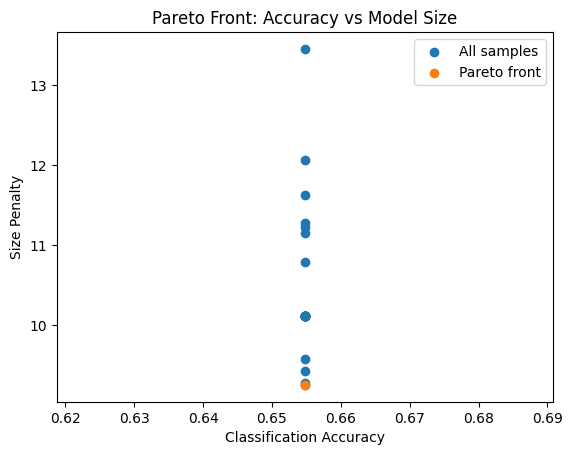

In [7]:
    # Plot Pareto front: Accuracy vs. Size Penalty
    plt.figure()
    plt.scatter(metrics[:, 0], metrics[:, 1], label='All samples')
    plt.scatter(metrics[pareto_mask, 0], metrics[pareto_mask, 1], label='Pareto front')
    # Sort Pareto points for connecting line
    front = metrics[pareto_mask]
    order = np.argsort(front[:, 0])
    plt.plot(front[order, 0], front[order, 1])
    plt.xlabel('Classification Accuracy')
    plt.ylabel('Size Penalty')
    plt.title('Pareto Front: Accuracy vs Model Size')
    # plt.gca().invert_yaxis()
    plt.legend()
    plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Dirichlet
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import math, numpy as np


# =========================================
# 0. Constants and other Parameters
# =========================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =========================================
# 1. Dirichlet Sampler
# =========================================
class DirichletSampler:
    def __init__(self, alpha):
        self.alpha = torch.tensor(alpha, dtype=torch.float)
        self.dist = Dirichlet(self.alpha)

    def sample(self):
        return self.dist.rsample()

# =========================================
# 2. ReinMax / Straight-Through Estimator
# =========================================
class ReinMaxSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits):
        probs = F.softmax(logits, dim=-1)
        idx = probs.argmax(dim=-1)
        one_hot = F.one_hot(idx, num_classes=logits.size(-1)).type_as(logits)
        ctx.save_for_backward(probs)
        return one_hot

    @staticmethod
    def backward(ctx, grad_output):
        (probs,) = ctx.saved_tensors
        return grad_output * probs * (1 - probs)

reinforce_max = ReinMaxSTE.apply

# =========================================
# 3. Choice Block & Cell Definition
# =========================================
class ChoiceBlock(nn.Module):
    def __init__(self, ops, dropout_p=0.0):
        super().__init__()
        self.ops = nn.ModuleList(ops)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x, logits):
        mask = reinforce_max(logits)
        for i, op in enumerate(self.ops):
            if mask[i] > 0:
                return self.dropout(op(x))
        return x

class Cell(nn.Module):
    def __init__(self, C, dropout_p=0.2, num_nodes=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_edges = sum(2 + i for i in range(num_nodes + 1))
        self.blocks = nn.ModuleList([
            ChoiceBlock([
                nn.Sequential(nn.Conv2d(C, C, 3, padding=1, groups=C), nn.Conv2d(C, C, 1)),
                nn.Sequential(nn.Conv2d(C, C, 5, padding=2, groups=C), nn.Conv2d(C, C, 1)),
                nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1), nn.Conv2d(C, C, 1)),
                nn.Identity()
            ], dropout_p=dropout_p)
            for _ in range(self.num_edges)
        ])

    def forward(self, s0, s1, logits):
        states = [s0, s1]
        offset = 0
        for _ in range(self.num_nodes):
            nb = len(states)
            node = sum(self.blocks[offset + j](h, logits[offset + j]) for j, h in enumerate(states))
            states.append(node)
            offset += nb
        return states[-1]



# -----------------------------------------
# 1) More expressive primitives
# -----------------------------------------
def sep_conv(C, kernel_size, stride, padding):
    """Depthwise-Separable Conv + BN + ReLU"""
    return nn.Sequential(
        nn.ReLU(inplace=False),
        nn.Conv2d(C, C, kernel_size, stride, padding,
                  groups=C, bias=False),
        nn.Conv2d(C, C, 1, bias=False),
        nn.BatchNorm2d(C),
    )

def dil_conv(C, kernel_size, stride, padding, dilation):
    """Dilated Conv + BN + ReLU"""
    return nn.Sequential(
        nn.ReLU(inplace=False),
        nn.Conv2d(C, C, kernel_size, stride,
                  padding, dilation=dilation, bias=False),
        nn.BatchNorm2d(C),
    )

def skip_connect():
    return nn.Identity()

def avg_pool(C, kernel_size, stride, padding):
    return nn.AvgPool2d(kernel_size, stride=stride, padding=padding)

def max_pool(C, kernel_size, stride, padding):
    return nn.MaxPool2d(kernel_size, stride=stride, padding=padding)

# -----------------------------------------
# 2) Improved ChoiceBlock with soft mixing
# -----------------------------------------
class MixedOp(nn.Module):
    def __init__(self, C):
        super().__init__()
        self._ops = nn.ModuleList([
            sep_conv(C, 3, 1, 1),
            sep_conv(C, 5, 1, 2),
            dil_conv(C, 3, 1, 2, dilation=2),
            nn.Sequential(nn.ReLU(inplace=False),
                          nn.Conv2d(C, C, 1, bias=False),
                          nn.BatchNorm2d(C)),
            avg_pool(C, 3, 1, 1),
            skip_connect(),
        ])

    def forward(self, x, weights):
        # weights: a (num_ops,) softmaxed vector
        return sum(w * op(x) for w, op in zip(weights, self._ops))

# -----------------------------------------
# 3) Bottleneck + residual Cell
# -----------------------------------------
class ResidualCell(nn.Module):
    def __init__(self, C, num_nodes=4):
        """
        - num_nodes: how many intermediate states per cell
        - uses a 1x1 bottleneck before mixed ops to reduce compute
        """
        super().__init__()
        self.num_nodes = num_nodes
        self.preprocess = nn.Sequential(
            nn.Conv2d(C, C, kernel_size=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=False),
        )
        # we'll compute edges from each existing state to each new state
        self.ops = nn.ModuleDict()
        for i in range(num_nodes + 1):    # +1 to include the initial input
            for j in range(i + 1, num_nodes + 1):
                key = f"{i}<-{j}"
                self.ops[key] = MixedOp(C)

        self.postprocess = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C * num_nodes, C, 1, bias=False),
            nn.BatchNorm2d(C),
        )

    def forward(self, s0, weights):
        """
        s0: input feature map
        weights: dict mapping 'i<-j' -> softmax weight vector for that edge
        """
        states = [self.preprocess(s0)]
        # build up intermediate states
        for new_idx in range(1, self.num_nodes + 1):
            sums = 0
            for prev_idx, h in enumerate(states):
                key = f"{prev_idx}<-{new_idx}"
                sums = sums + self.ops[key](h, weights[key])
            states.append(sums)
        # concat all intermediate states (excluding the initial)
        concat = torch.cat(states[1:], dim=1)  # (B, C * num_nodes, H, W)
        return self.postprocess(concat) + s0   # residual

# -----------------------------------------
# 4) How to generate the weights dict
# -----------------------------------------
class CellArchParam(nn.Module):
    def __init__(self, C, num_nodes=4, num_ops=6):
        super().__init__()
        # one learnable vector per edge
        self.alphas = nn.ParameterDict()
        for i in range(num_nodes + 1):
            for j in range(i + 1, num_nodes + 1):
                self.alphas[f"{i}<-{j}"] = nn.Parameter(
                    1e-3 * torch.randn(num_ops)
                )

    def forward(self, logits_slice):
        # logits_slice: Tensor [num_edges_this_cell, num_ops]
        return {
            key: F.softmax(logits_slice[i], dim=-1)
            for i, key in enumerate(self.alphas.keys())
        }


# =========================================
# 4. HyperNetwork
# =========================================
class HyperNetwork(nn.Module):
    def __init__(self, num_blocks, num_ops, hidden_dim=128, depth=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(2, hidden_dim))
        for _ in range(depth-1):
            layers += [
                nn.ReLU(inplace=False),
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim)      # ← use LayerNorm instead
            ]
        self.mlp    = nn.Sequential(*layers)
        self.fc_out = nn.Linear(hidden_dim, num_blocks * num_ops)
        self.num_blocks = num_blocks
        self.num_ops    = num_ops

    def forward(self, lambda_vec):
        # allow lambda_vec to be either [2] or [B,2]
        x = lambda_vec
        if x.dim() == 1:
            x = x.unsqueeze(0)         # now [1,2]
        h = self.mlp(x)                # [B, hidden_dim]
        out = self.fc_out(h)           # [B, num_blocks*num_ops]
        out = out.view(-1, self.num_blocks, self.num_ops)
        if lambda_vec.dim() == 1:
            out = out.squeeze(0)       # back to [num_blocks, num_ops]
        return out


# =========================================
# 5. SuperNetwork (Classification Only)
# =========================================

class SuperNetwork(nn.Module):
    def __init__(self, C=16, num_cells=4, num_nodes=4, num_ops=6, dropout_p=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, C, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=False),
            nn.Dropout(dropout_p)
        )
        self.cells = nn.ModuleList()
        for _ in range(num_cells):
            # Each cell has its own architecture params and residual cell
            arch_param = CellArchParam(C, num_nodes=num_nodes, num_ops=num_ops)
            cell_body = ResidualCell(C, num_nodes=num_nodes)
            self.cells.append(nn.ModuleDict({
                'arch': arch_param,
                'body': cell_body
            }))
        
        # after all cells are added, record counts:
        self.num_blocks = sum(len(cell['arch'].alphas) for cell in self.cells)
        # all alphas share same op‐dim:
        first_alpha = next(iter(self.cells[0]['arch'].alphas.values()))
        self.num_ops   = first_alpha.shape[0]

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(C, 10)
        )

    def forward(self, x, arch_logits):
        out = self.stem(x)
        offset = 0
        for cell in self.cells:
            # num_edges for this cell
            ne = len(cell['arch'].alphas)
            # grab the right chunk
            logits_slice = arch_logits[offset:offset+ne]  # [ne, num_ops]
            weights      = cell['arch'](logits_slice)     # softmax over each row
            out          = cell['body'](out, weights)
            offset      += ne
        gap = self.global_pool(out).view(x.size(0), -1)
        return self.cls_head(gap)



# =========================================
# 7. Training Loop (Classification + Size)
# =========================================

def train(num_epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ————— define rays here —————
    NUM_RAYS = 60
    thetas   = np.linspace(1e-3, math.pi/2 - 1e-3, NUM_RAYS)
    rays     = [
        torch.tensor([math.cos(t), math.sin(t)], device=device, dtype=torch.float)
        for t in thetas
    ]


    # ————— Data —————
    transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    cifar     = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=transform)
    train_set, val_set = random_split(cifar, [45000, 5000])
    train_loader = DataLoader(train_set, batch_size=128,
                              shuffle=True, num_workers=4)
    val_loader   = DataLoader(val_set,   batch_size=128,
                              shuffle=False, num_workers=4)

    # ————— Model & Search —————
    sampler     = DirichletSampler([10.0, 1.0])  # cls vs size
    supernet    = SuperNetwork().to(device)
    num_blocks = supernet.num_blocks
    num_ops    = supernet.num_ops
    hypernet    = HyperNetwork(num_blocks, num_ops).to(device)


    # ————— Opts & Loss —————
    opt_w       = torch.optim.SGD(supernet.parameters(),
                                  lr=0.025, momentum=0.9,
                                  weight_decay=3e-4)
    opt_theta   = torch.optim.SGD(hypernet.parameters(),
                                  lr=0.01, momentum=0.9)
    criterion   = nn.CrossEntropyLoss()

    # ————— Precompute size counts —————
    op_counts = []
    for cell in supernet.cells:
        body: ResidualCell = cell['body']
        # body.ops is a ModuleDict mapping edge-key -> MixedOp
        for mixed_op in body.ops.values():
            # mixed_op._ops is the list of nn.Modules we mix over
            sizes = [sum(p.numel() for p in op.parameters())
                     for op in mixed_op._ops]
            op_counts.append(sizes)

    counts = torch.tensor(op_counts, device=device, dtype=torch.float)
    # per‐edge maximum
    max_per_edge = counts.max(dim=1).values     # shape [num_edges]

    # total worst‐case size
    max_size     = max_per_edge.sum()           # scalar

    # ————— Training Loop —————
    epoch_iter = tqdm(range(1, num_epochs+1),
                      desc="Overall Training", unit="epoch")
    for epoch in epoch_iter:
        supernet.train()
        hypernet.train()

        # --- inside your epoch, replacing MGDA update --- #

        # 1) Sample λ to condition the hypernet
        lambda_vec = sampler.sample().to(device)

        # We'll collect per-ray losses & grads
        ray_losses = []    # list of (cls_loss, size_loss)
        ray_grads  = []    # list of flattened grad vectors

        x_val, y_val = next(iter(val_loader))
        x_val, y_val = x_val.to(device), y_val.to(device)

        for r in rays:
            hypernet.zero_grad()

            # forward
            arch_logits = hypernet(r)                # [num_blocks, num_ops]
            out_val     = supernet(x_val, arch_logits)

            # two objectives
            loss_cls  = criterion(out_val, y_val)
            loss_size = (reinforce_max(arch_logits) * counts).sum() / max_size

            # record losses (for nondomination sorting)
            ray_losses.append((loss_cls.item(), loss_size.item()))

            # backprop a *linear scalarization* for this ray
            L = r[0]*loss_cls + r[1]*loss_size
            L.backward()

            # flatten and store the gradient
            flat_g = torch.cat([
                p.grad.detach().flatten() 
                for p in hypernet.parameters()
            ])
            ray_grads.append(flat_g)

            # clear for next ray
            opt_theta.zero_grad()

        ray_losses = np.array(ray_losses)  # shape [NUM_RAYS, 2]
        ray_grads   = torch.stack(ray_grads)  # shape [NUM_RAYS, D]

        def is_pareto_efficient(costs):
            """
            Find Pareto-efficient points in a cost array (to minimize each column).
            Returns a boolean mask.
            """
            is_efficient = np.ones(costs.shape[0], dtype=bool)
            for i, c in enumerate(costs):
                if is_efficient[i]:
                    is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
                    is_efficient[i] = True
            return is_efficient

        # 2) Pareto‐front selection
        mask_front = is_pareto_efficient(np.stack([
            ray_losses[:,0],   # minimize cls_loss
            ray_losses[:,1]    # minimize size_loss
        ], axis=1))

        front_grads = ray_grads[mask_front]  # the gradients of Pareto rays

        # 3) (Optional) crowding‐distance prune to at most K rays
        K = 10   # or whatever population size you prefer

        # get the indices of the Pareto‐front within the full ray set
        front_indices = np.nonzero(mask_front)[0]
        front_losses  = ray_losses[mask_front]   # shape [F, 2] where F = len(front_indices)

        # 3a) compute crowding distances for each point in the front
        def crowding_distance(losses):
            # losses: numpy array shape [F, 2], columns = [loss_cls, loss_size]
            F = losses.shape[0]
            dist = np.zeros(F)
            # for each objective m = 0,1
            for m in range(2):
                order = np.argsort(losses[:, m])
                dist[order[0]] = dist[order[-1]] = np.inf
                lo = losses[order[0], m]
                hi = losses[order[-1], m]
                denom = hi - lo + 1e-12
                for i in range(1, F-1):
                    prev, nxt = losses[order[i-1], m], losses[order[i+1], m]
                    dist[order[i]] += (nxt - prev) / denom
            return dist

        distances = crowding_distance(front_losses)  # shape [F]

        # 3b) pick the top-K points by descending distance
        if len(front_indices) > K:
            keep_order = np.argsort(-distances)[:K]   # indices into front_indices
            keep_front = front_indices[keep_order]
        else:
            keep_front = front_indices

        # now gather their gradients
        selected_grads = ray_grads[keep_front]       # shape [<=K, D]

        # 4) average the selected gradients
        g_avg = selected_grads.mean(dim=0)

        # scatter back into hypernet.parameters().grad (as before)
        offset = 0
        for p in hypernet.parameters():
            n = p.numel()
            p.grad = g_avg[offset:offset+n].view_as(p)
            offset += n

        # 5) step
        opt_theta.step()



        # 3) SuperNet update (cls only) w/ tqdm
        cls_ray = torch.tensor([1.0, 0.0], device=device)
        train_iter = tqdm(train_loader,
                          desc=f"Epoch {epoch:02d} | Weight update",
                          leave=False, unit="batch")
        for x_tr, y_tr in train_iter:
            x_tr, y_tr = x_tr.to(device), y_tr.to(device)

            arch_logits = hypernet(cls_ray)
            out_tr      = supernet(x_tr, arch_logits)
            loss_tr     = criterion(out_tr, y_tr)

            opt_w.zero_grad()
            loss_tr.backward()
            opt_w.step()

            train_iter.set_postfix_str(
                f"cls_loss: {loss_tr.item():.4f}"
            )

        # 4) Log the hypernet (val) losses every epoch
        epoch_iter.set_postfix({
            'val_cls':  f"{loss_cls.item():.4f}",
            'val_size': f"{loss_size.item():.4f}"
        })


    torch.save({'supernet': supernet.state_dict(), 'hypernet': hypernet.state_dict()}, 'checkpoint.pth')

if __name__ == "__main__":
    train(10)


Overall Training: 100%|██████████| 10/10 [02:36<00:00, 15.65s/epoch, val_cls=1.0261, val_size=0.1928]


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os

# =========================================
# Pareto Front Visualization and Scratch Training
# =========================================

def is_pareto_efficient(costs):
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return is_efficient


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Load checkpoint
chk = torch.load('checkpoint.pth', map_location=device)

# Reconstruct networks
supernet = SuperNetwork().to(device)
supernet.load_state_dict(chk['supernet'])
num_blocks = sum(c.num_edges for c in supernet.cells)
num_ops = len(supernet.cells[0].blocks[0].ops)
hypernet = HyperNetwork(num_blocks, num_ops).to(device)
hypernet.load_state_dict(chk['hypernet'])

# Recompute size costs
op_counts = [[sum(p.numel() for p in op.parameters()) for op in block.ops]
                for cell in supernet.cells for block in cell.blocks]
counts_tensor = torch.tensor(op_counts, device=device, dtype=torch.float)
max_size = float(sum(max(c) for c in op_counts))

# Samplers
nas_sampler = DirichletSampler([1.0, 0.1])
rand_sampler = lambda: torch.randn(num_blocks, num_ops, device=device)

# Sample metrics
n_samples = 50
nas_metrics = []
rand_metrics = []
arch_nas = []
arch_rand = []
for _ in range(n_samples):
    lam = nas_sampler.sample().to(device)
    logits = hypernet(lam)
    res = evaluate(supernet, logits, counts_tensor, max_size, device)
    nas_metrics.append([res['cls_acc'], res['size_penalty']])
    arch_nas.append(logits.clone())

    logits_r = rand_sampler()
    res_r = evaluate(supernet, logits_r, counts_tensor, max_size, device)
    rand_metrics.append([res_r['cls_acc'], res_r['size_penalty']])
    arch_rand.append(logits_r.clone())

nas_metrics = np.array(nas_metrics)
rand_metrics = np.array(rand_metrics)

# Identify Pareto fronts
costs_n = np.stack([-nas_metrics[:,0], nas_metrics[:,1]], axis=1)
costs_r = np.stack([-rand_metrics[:,0], rand_metrics[:,1]], axis=1)
pareto_n = is_pareto_efficient(costs_n)
pareto_r = is_pareto_efficient(costs_r)

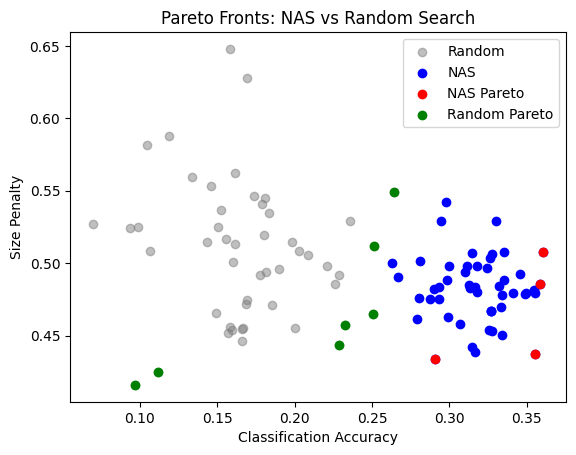

In [6]:
# Plot both
plt.figure()
plt.scatter(rand_metrics[:,0], rand_metrics[:,1], c='gray', alpha=0.5, label='Random')
plt.scatter(nas_metrics[:,0], nas_metrics[:,1], c='blue', label='NAS')
plt.scatter(nas_metrics[pareto_n,0], nas_metrics[pareto_n,1], c='red', label='NAS Pareto')
plt.scatter(rand_metrics[pareto_r,0], rand_metrics[pareto_r,1], c='green', label='Random Pareto')
plt.xlabel('Classification Accuracy')
plt.ylabel('Size Penalty')
plt.title('Pareto Fronts: NAS vs Random Search')
plt.legend()
plt.show()

In [10]:
# =========================================
# Fully Corrected Scratch Training with Improvements
# =========================================
def train_scratch(arch_logits, counts_tensor, max_size, device, epochs=50):
    # 1) Get chosen op index per block
    arch_indices = arch_logits.argmax(dim=-1).tolist()
    C = 16
    num_cells = len(supernet.cells)

    class StaticSuperNetwork(nn.Module):
        def __init__(self, C, supernet, arch_indices):
            super().__init__()
            # fresh stem
            self.stem = nn.Sequential(
                nn.Conv2d(3, C, 3, stride=2, padding=1),
                nn.BatchNorm2d(C), nn.ReLU(),
                nn.Dropout(0.3)
            )
            self.cells = nn.ModuleList()
            idx = 0
            # mirror original DAG: inputs = [s0, s1]
            for cell in supernet.cells:
                ops = []
                for block in cell.blocks:
                    choice = arch_indices[idx]
                    base_op = block.ops[choice]
                    # deep clone op structure
                    op_clone = type(base_op)(*base_op.__dict__.get('args', []), **base_op.__dict__.get('kwargs', {}))
                    # re-init weights
                    for m in op_clone.modules():
                        if isinstance(m, nn.Conv2d):
                            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                        elif isinstance(m, nn.BatchNorm2d):
                            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
                    ops.append(nn.Sequential(op_clone, nn.Dropout(0.2)))
                    idx += 1
                self.cells.append(nn.ModuleList(ops))
            # expanded head
            self.cls_head = nn.Sequential(
                nn.Linear(C, C*4), nn.ReLU(), nn.Dropout(0.4),
                nn.Linear(C*4, 10)
            )

        def forward(self, x, _):
            s0 = s1 = self.stem(x)
            for cell_ops in self.cells:
                outs = []
                # alternate inputs: s0 and s1
                for j, op in enumerate(cell_ops):
                    inp = [s0, s1][j % 2]
                    outs.append(op(inp))
                out = sum(outs)
                s0, s1 = s1, out
            gap = F.adaptive_avg_pool2d(s1, 1).view(x.size(0), -1)
            return self.cls_head(gap)

    model = StaticSuperNetwork(C, supernet, arch_indices).to(device)

    # 2) Optimizer & LR scheduler (ReduceLROnPlateau)
    opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # 3) Data + augmentation + early stopping
    transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.4,0.4,0.4,0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616)),
    ])
    cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    train_set, val_set = random_split(cifar, [45000, 5000])
    train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=4)
    val_loader   = DataLoader(val_set,   batch_size=128, shuffle=False, num_workers=4)

    best_val_acc = 0.0
    patience = 15
    stale = 0
    best_weights = None

    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            out = model(x, None)
            loss = criterion(out, y)
            opt.zero_grad(); loss.backward();
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        # validate
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x, None).argmax(dim=1)
                correct += (preds==y).sum().item(); total += y.size(0)
        val_acc = correct/total
        scheduler.step(val_acc)
        print(f"Epoch {ep}: Train Loss={loss:.4f}, Val Acc={val_acc:.4f}, LR={scheduler.get_last_lr()[0]:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc; stale = 0; best_weights = model.state_dict()
        else:
            stale += 1
            if stale >= patience:
                print(f"Early stopping at epoch {ep}, val_acc={val_acc:.4f}")
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)

    # final evaluation
    res = evaluate(model, arch_logits, counts_tensor, max_size, device)
    return model, res['cls_acc']


# ===============================
# Example: Applying to top architectures
# ===============================
num_samples = 2
num_epochs = 30

# top NAS indices from Pareto
idx_n = np.where(pareto_n)[0][:num_samples]
idx_r = np.where(pareto_r)[0][:num_samples]


nas_models, rand_models = [], []
nas_trained_metrics, rand_trained_metrics = [], []

for i in idx_n[:num_samples]:
    model, acc = train_scratch(arch_nas[i], counts_tensor, max_size, device, epochs=num_epochs)
    one_hot = torch.nn.functional.one_hot(arch_nas[i].argmax(dim=-1), num_ops).float().to(device)
    size_p = (one_hot * counts_tensor).sum().item() / max_size
    nas_models.append(model)
    nas_trained_metrics.append([acc, size_p])

for i in idx_r[:num_samples]:
    model, acc = train_scratch(arch_rand[i], counts_tensor, max_size, device, epochs=num_epochs)
    one_hot = torch.nn.functional.one_hot(arch_rand[i].argmax(dim=-1), num_ops).float().to(device)
    size_p = (one_hot * counts_tensor).sum().item() / max_size
    rand_models.append(model)
    rand_trained_metrics.append([acc, size_p])


nas_trained_metrics = np.array(nas_trained_metrics)
rand_trained_metrics = np.array(rand_trained_metrics)

Epoch 0: Train Loss=2.3031, Val Acc=0.1018, LR=0.010000
Epoch 1: Train Loss=2.3023, Val Acc=0.0948, LR=0.010000
Epoch 2: Train Loss=2.3003, Val Acc=0.1018, LR=0.010000
Epoch 3: Train Loss=2.3020, Val Acc=0.0948, LR=0.005000
Epoch 4: Train Loss=2.3035, Val Acc=0.0982, LR=0.005000
Epoch 5: Train Loss=2.3020, Val Acc=0.0948, LR=0.005000
Epoch 6: Train Loss=2.3021, Val Acc=0.0948, LR=0.002500
Epoch 7: Train Loss=2.3030, Val Acc=0.0948, LR=0.002500
Epoch 8: Train Loss=2.3030, Val Acc=0.0948, LR=0.002500
Epoch 9: Train Loss=2.3027, Val Acc=0.0982, LR=0.001250
Epoch 10: Train Loss=2.3025, Val Acc=0.0982, LR=0.001250
Epoch 11: Train Loss=2.3020, Val Acc=0.0948, LR=0.001250
Epoch 12: Train Loss=2.3030, Val Acc=0.0948, LR=0.000625
Epoch 13: Train Loss=2.3027, Val Acc=0.0948, LR=0.000625
Epoch 14: Train Loss=2.3022, Val Acc=0.0948, LR=0.000625
Epoch 15: Train Loss=2.3027, Val Acc=0.0948, LR=0.000313
Early stopping at epoch 15, val_acc=0.0948
Epoch 0: Train Loss=2.3020, Val Acc=0.1044, LR=0.010000

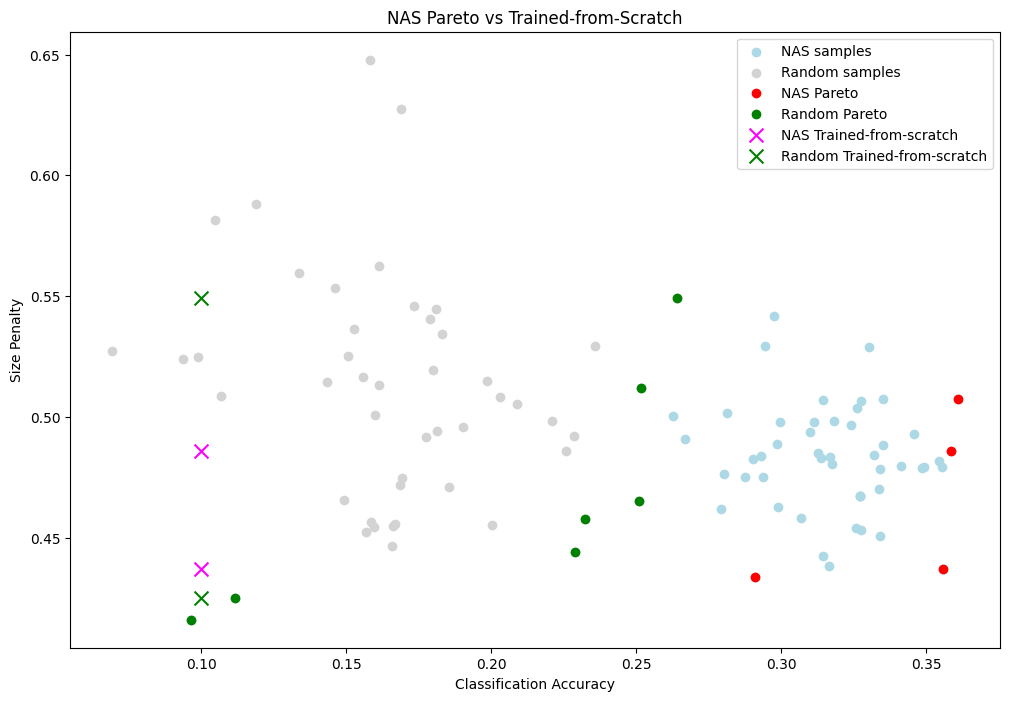

In [9]:
# Plot with true trained points
plt.figure(figsize=(12,8))
plt.scatter(nas_metrics[:,0], nas_metrics[:,1], c='lightblue', label='NAS samples')
plt.scatter(rand_metrics[:,0], rand_metrics[:,1], c='lightgray', label='Random samples')
plt.scatter(nas_metrics[pareto_n,0], nas_metrics[pareto_n,1], c='red', label='NAS Pareto')
plt.scatter(rand_metrics[pareto_r,0], rand_metrics[pareto_r,1], c='green', label='Random Pareto')

plt.scatter(nas_trained_metrics[:,0], nas_trained_metrics[:,1], c='magenta', marker='x', s=100, label='NAS Trained-from-scratch')
plt.scatter(rand_trained_metrics[:,0], rand_trained_metrics[:,1], c='green', marker='x', s=100, label='Random Trained-from-scratch')

plt.xlabel('Classification Accuracy')
plt.ylabel('Size Penalty')
plt.title('NAS Pareto vs Trained-from-Scratch')
plt.legend()
plt.show()

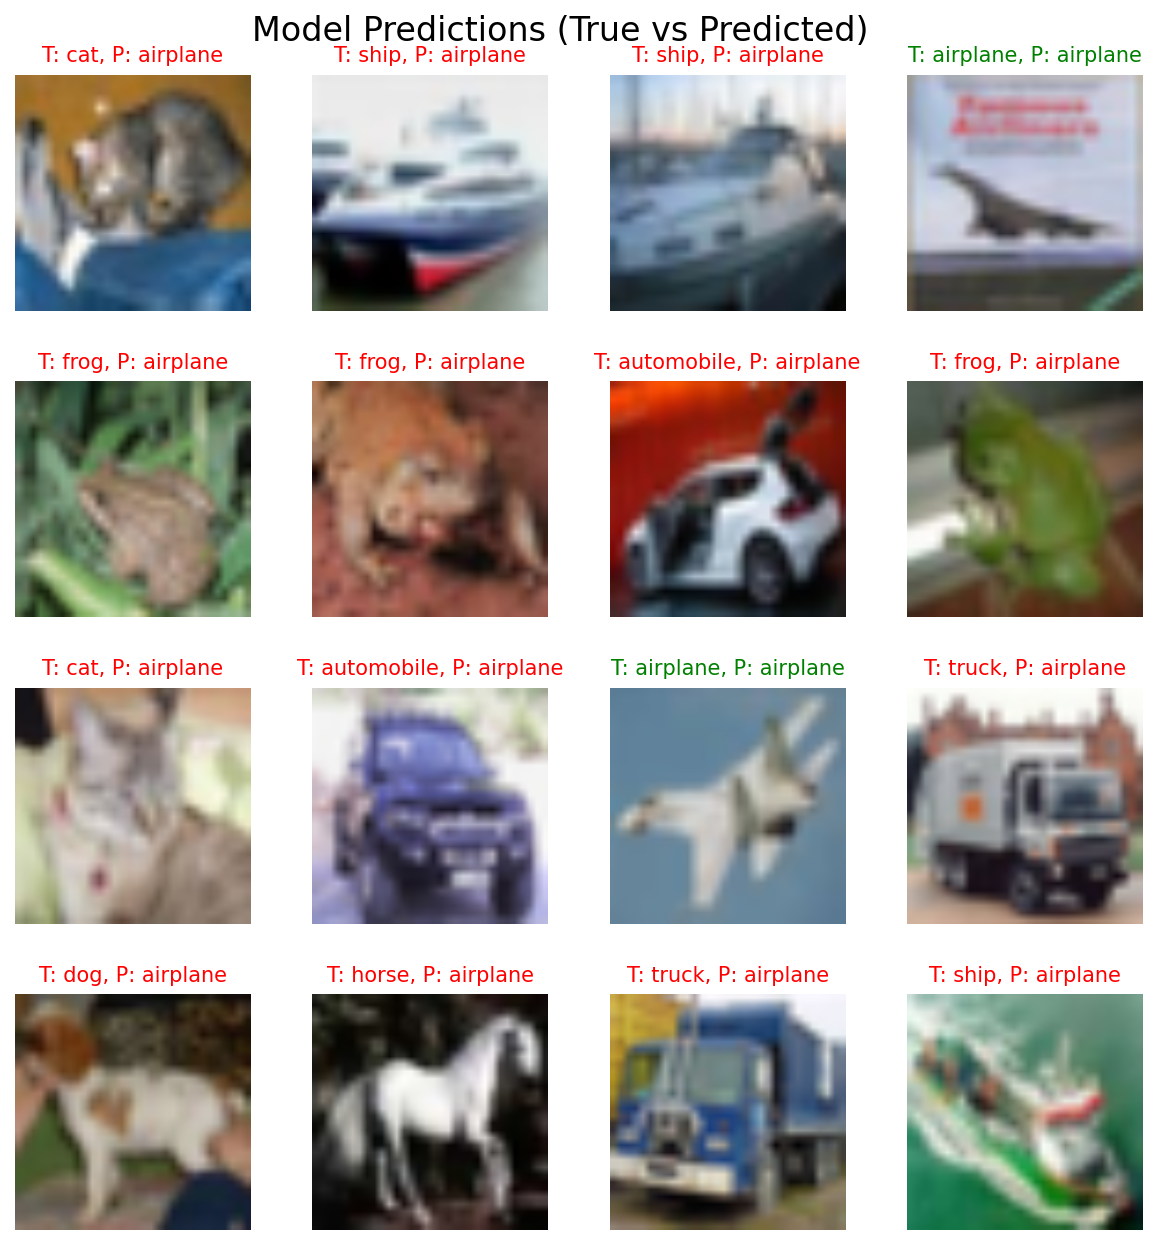

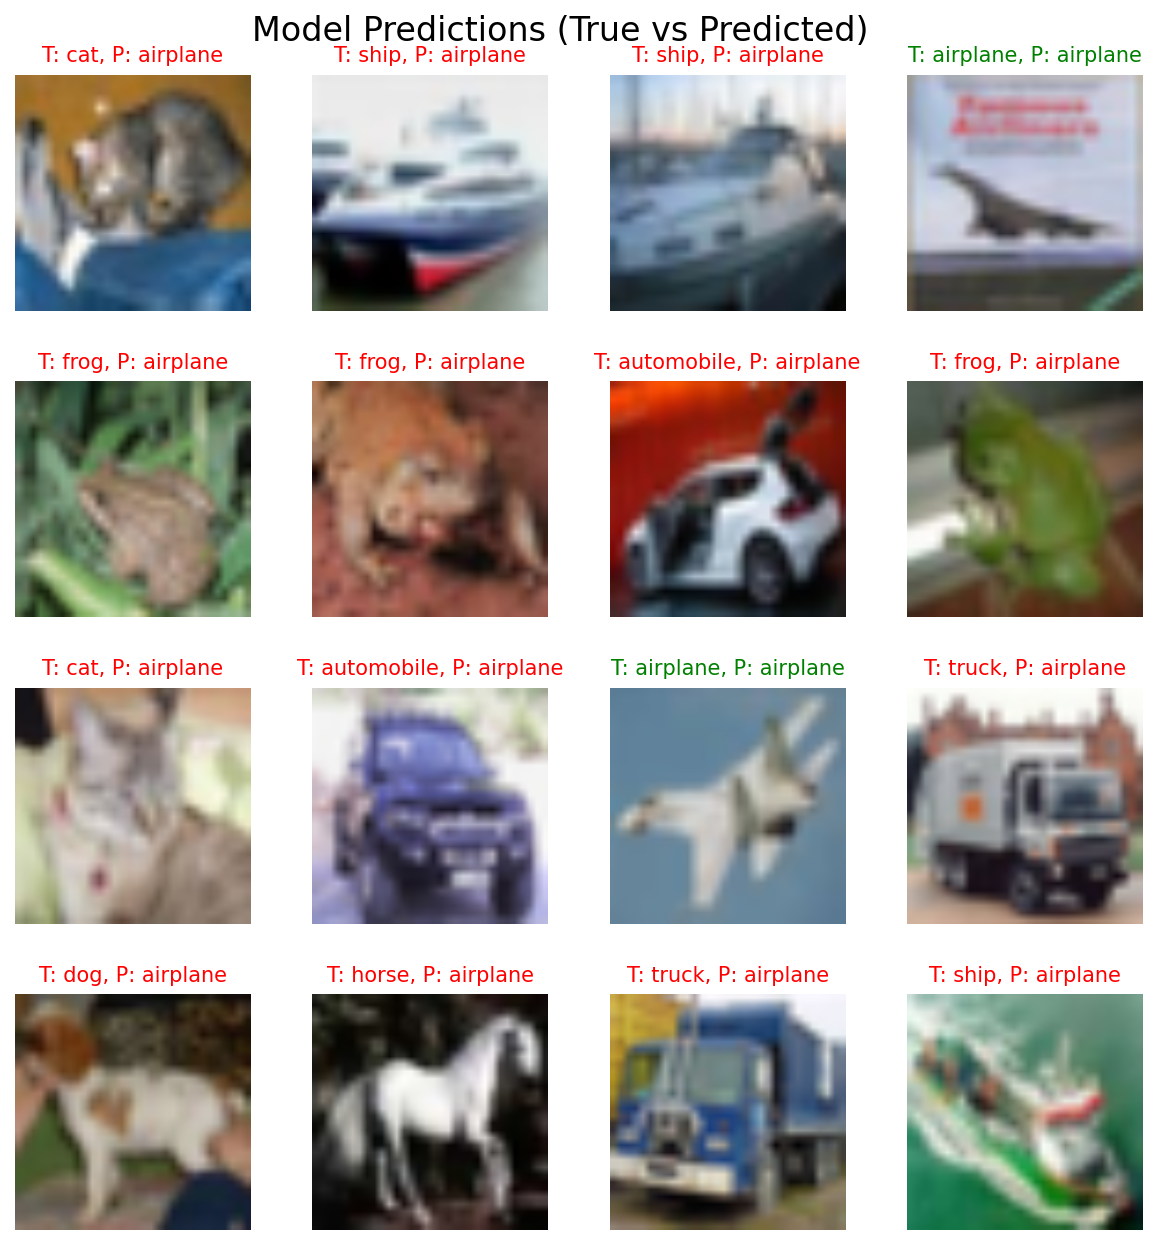

In [ ]:
test_models = [nas_models[0], rand_models[0]]
for model in test_models:
    # Visualize on CIFAR-10 val set using the returned model
    transform_val = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616)),
    ])
    cifar_val = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_val)
    loader_val = DataLoader(cifar_val, batch_size=16, shuffle=False)
    images, labels = next(iter(loader_val))
    images, labels = images.to(device), labels.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(images, None)
        preds = outputs.argmax(dim=1)

    # Plot a 4x4 grid of images with true vs predicted labels
    classes = cifar_val.classes
    fig, axes = plt.subplots(4, 4, figsize=(10,10), dpi=150)
    for i, ax in enumerate(axes.flatten()):
        if i >= images.size(0):
            ax.axis('off')
            continue
        img = images[i].cpu().permute(1,2,0).numpy()
        # Denormalize
        mean = np.array([0.4914, 0.4822, 0.4465])
        std  = np.array([0.2470, 0.2435, 0.2616])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img, interpolation='bilinear')
        ax.axis('off')
        true_label = classes[labels[i].item()]
        pred_label = classes[preds[i].item()]
        color = 'green' if preds[i]==labels[i] else 'red'
        ax.set_title(f"T: {true_label}, P: {pred_label}", color=color, fontsize=10)
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    fig.suptitle('Model Predictions (True vs Predicted)', y=0.92, fontsize=16)
    plt.show()
